<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/main/MultipleLinerRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**In this session we will discuss About Multiple Linear Regression**

---



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

df=pd.read_csv("/content/sample_data/economic_index.csv")
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [31]:
import os

# List contents of your Google Drive to find the correct path
# You might need to adjust the path if your file is in a subfolder
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for name in files:
        if 'economic_index.csv' in name:
            print(os.path.join(root, name))


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**In ths data set we used three coloum ,interest_rate	unemployment_rate,	index_price.**

In [12]:
#drop unneccessary columns
df.drop(columns=['year','month','Unnamed: 0'],axis=1,inplace=True, errors='ignore')
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [13]:
#Check Null values
df.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


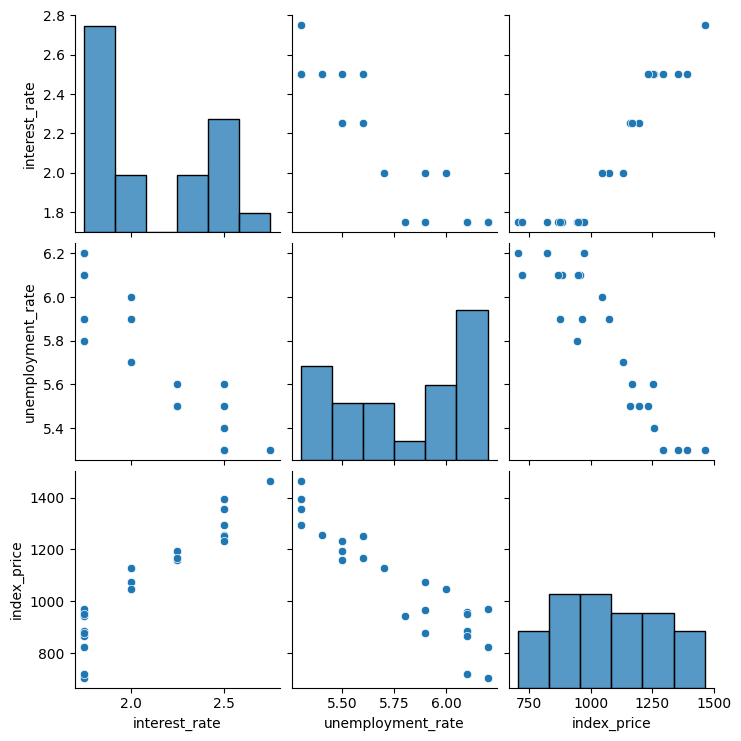

In [ ]:
#Lets see the visualization
import seaborn as sns
sns.pairplot(df)


In [14]:
#Check the correlation ech other

df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


AttributeError: module 'matplotlib.pyplot' has no attribute 'yblabe'

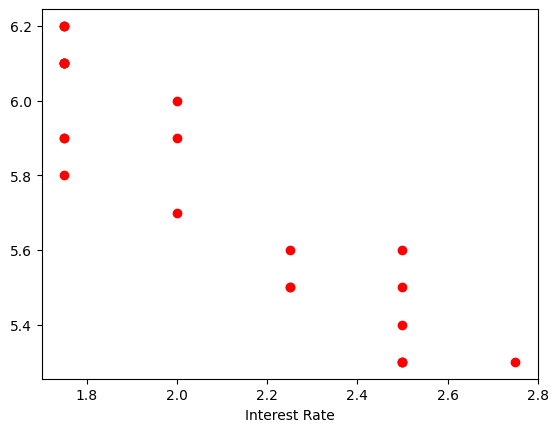

In [15]:
from matplotlib import colors
#Visualiza the datapoint more closely
plt.scatter(df['interest_rate'],df['unemployment_rate'],c='red')
plt.xlabel("Interest Rate")
plt.yblabe("")

Text(0, 0.5, 'Unemployement rate')

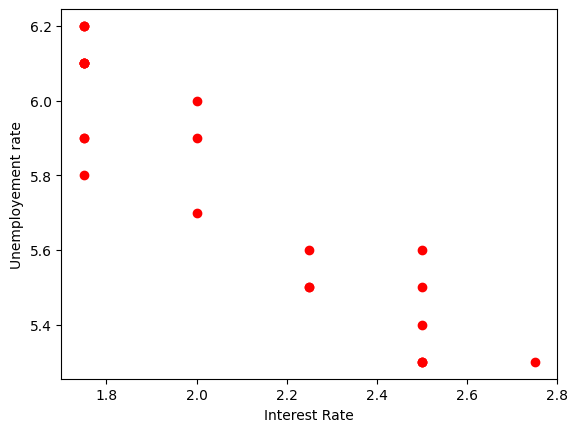

In [ ]:
from matplotlib import colors
#Visualiza the datapoint more closely
plt.scatter(df['interest_rate'],df['unemployment_rate'],c='red')
plt.xlabel("Interest Rate")
plt.ylabel("Unemployement rate")

In [16]:
#independent and dependent feature
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [ ]:
y

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256
5,1254
6,1234
7,1195
8,1159
9,1167


In [19]:
#Train test split

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

We use **sns.regplot** from the Seaborn library to plot a scatter plot with a linear regression line automatically drawn through the data points.It is a powerful tool for visual data analysis because it instantly shows you the relationship and trend between two numerical variables.


In [20]:
sns.regplot(x='interest_rate', y='unemployment_rate', data=df)

NameError: name 'sns' is not defined

<Axes: xlabel='interest_rate', ylabel='index_price'>

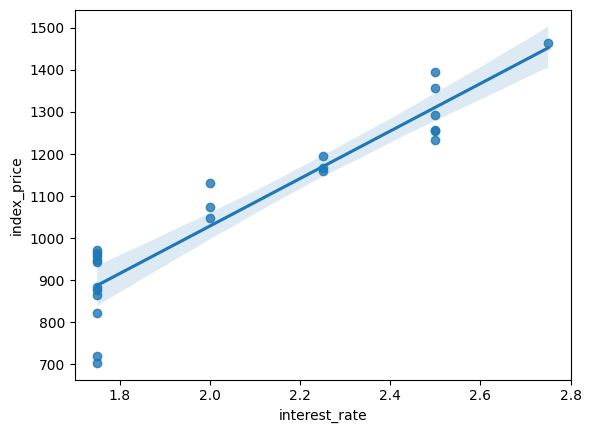

In [ ]:
sns.regplot(x='interest_rate',y='index_price',data=df)

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

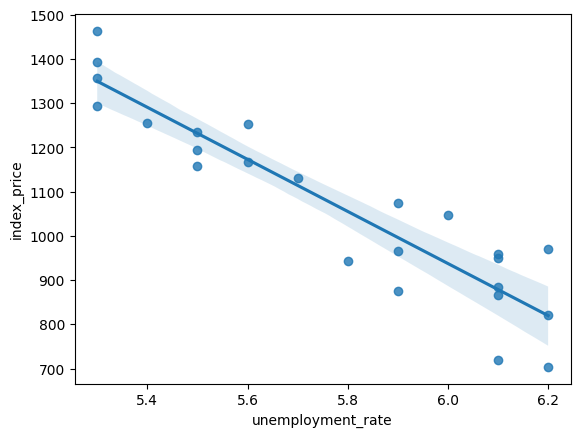

In [ ]:
sns.regplot(x='unemployment_rate',y='index_price',data=df)

In [24]:
from sklearn.preprocessing import StandardScaler
score=StandardScaler()
x_train=score.fit_transform(x_train)
x_test=score.transform(x_test)

x_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

***fit():*** The algorithm analyzes the column to calculate the underlying statistics. For example, if you are scaling data using StandardScaler, fit() calculates the mean and standard deviation.

***transform():*** The algorithm uses those exact calculated statistics to mathematically modify the values in your dataset.

***fit_transform():*** Does both. It calculates the mean and standard deviation, and then immediately transforms the numbers.



In [22]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(x_train,y_train)


LinearRegression()

***why we used cross_val_score***

---


We use cross_val_score to reliably evaluate a machine learning model's performance and ensure it generalizes well to unseen data. Instead of relying on a single train-test split—which can yield overly optimistic or pessimistic results depending on how the data was randomly sliced—cross_val_score automatically splits, trains, and tests the model multiple times to give an honest, averaged performance metric

In [25]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,x_train,y_train,scoring='neg_root_mean_squared_error',cv=3)

In [26]:
validation_score

array([-70.15421094, -87.67482519, -71.66586534])

In [27]:
np.mean(validation_score)

np.float64(-76.49830049161146)

In [29]:
#Prediction

y_pred=regression.predict(x_test)
y_pred

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3061.63693931, 1894.8674661 , 3669.2122312 , 2006.70630237,
       2422.33278458, 2949.79810305])

In [32]:
from sklearn.metrics  import mean_squared_error,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("Mean Squared Error:",mse)
print("Mean Absolute Error:",mae)
print("Root Mean Squared Error:",rmse)

Mean Squared Error: 2598443.9254013035
Mean Absolute Error: 1547.425637768456
Root Mean Squared Error: 1611.9689591928573


In [35]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)
#Disply adjusted R squared
print(1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1))

-76.18608804685337
-127.64348007808894


**Assumption**

Text(0, 0.5, 'Predicted')

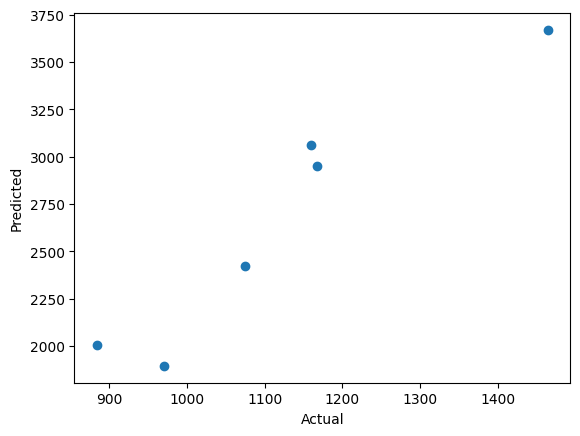

In [37]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [38]:
residual=y_test-y_pred
print(residual)

8    -1902.636939
16    -923.867466
0    -2205.212231
18   -1122.706302
11   -1347.332785
9    -1782.798103
Name: index_price, dtype: float64


/tmp/ipykernel_24098/2764967526.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual)


<Axes: xlabel='index_price', ylabel='Density'>

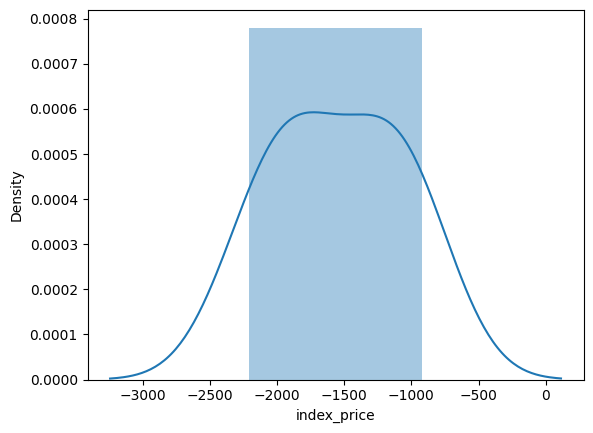

In [40]:
import seaborn as sns
#Plot this residuals

sns.distplot(residual,kind='kde')

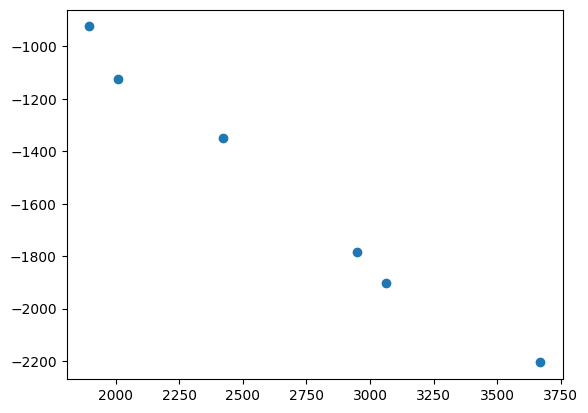

In [41]:
##Scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residual)

***[With respect to OLS Linear Regression](https://)***

---
OLS stands for Ordinary Least Squares. It is the most common mathematical method used to estimate the unknown parameters (coefficients) in a linear regression model.Its primary objective is to find the "line of best fit" through your data points by minimizing the sum of the squared differences (residuals) between the actual data points and the line's predictions.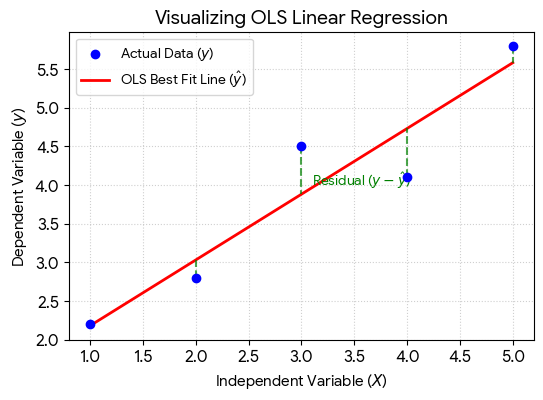


In [42]:
import statsmodels.api as sm
model=sm.OLS(y_train,x_train).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sun, 17 May 2026   Prob (F-statistic):                       0.754
Time:                        10:48:57   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""